In [1]:
%matplotlib widget
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 167 imported


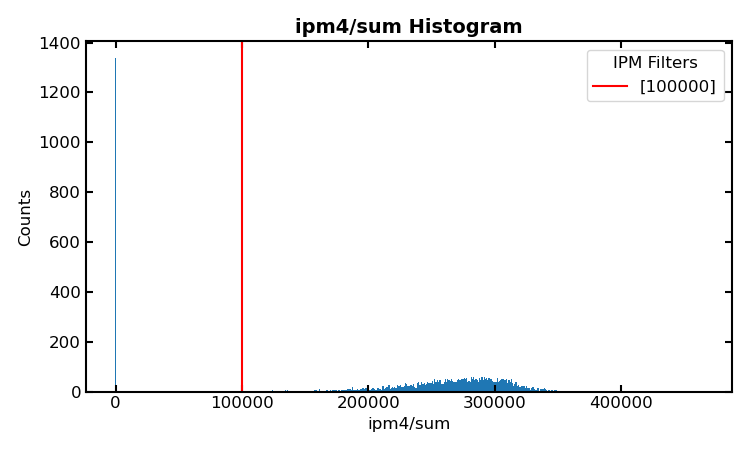

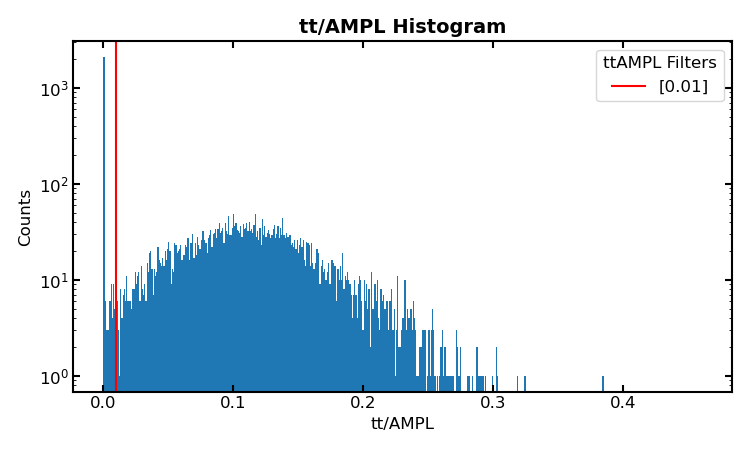

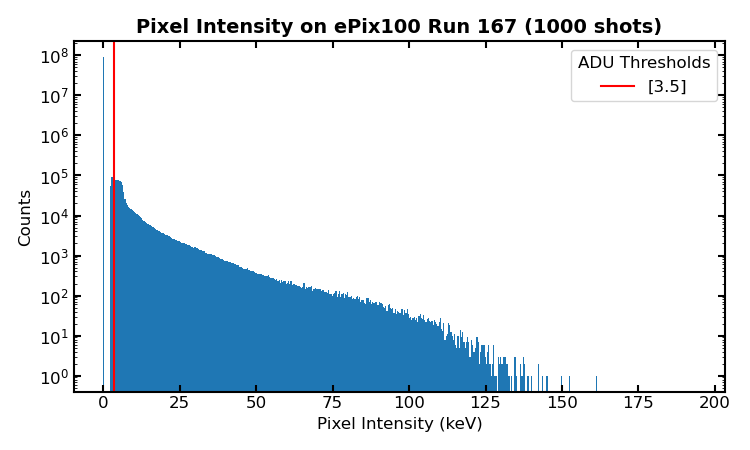

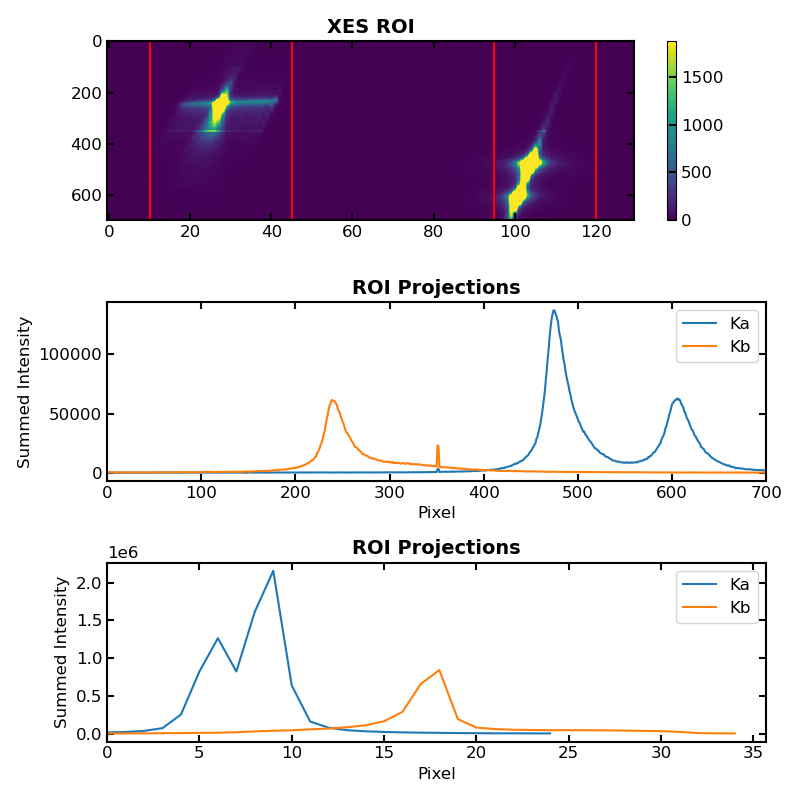

Rotating image by 1.4 degree(s)


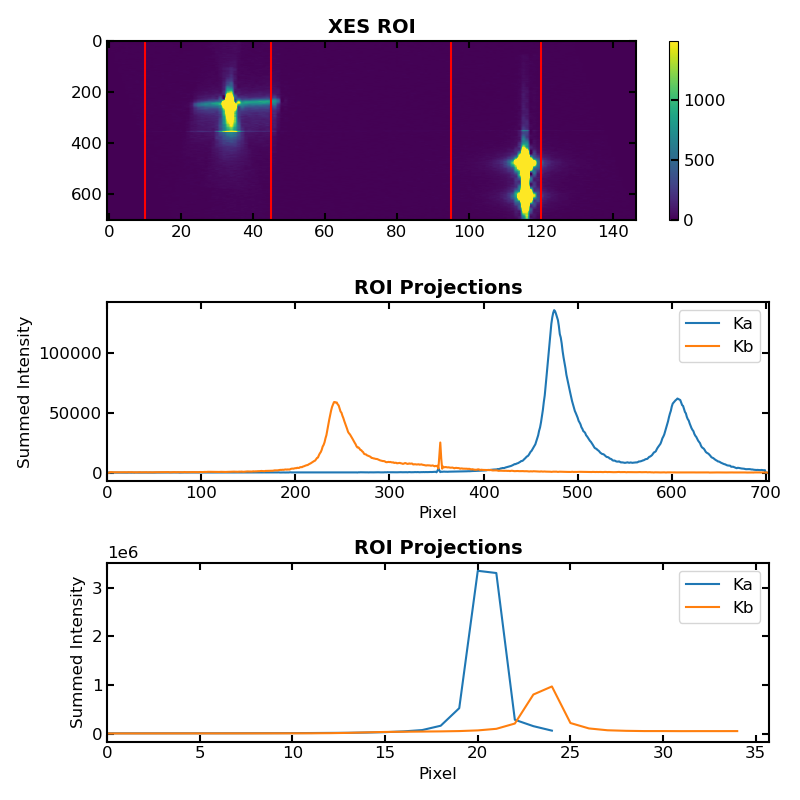

Text(0.5, 32.99999999999998, 'shot #')

In [2]:
run = 167
exp = 'xcs101230225'
keys=['epics/dccm_E','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_2/ROI_area'] 
names=['energy','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']

# pdf = PdfPages("output.pdf")

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [100000]

d.ipm_histogram(ipm_thres)

# figx = plt.gcf()
# pdf.savefig(figx)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

adu_thres = [3.5]
d.adu_histogram(nshots, adu_thres)

# ka_roi_d = [270, 300]
# kb_roi_d = [180, 220]

# d.detector_sum_ROI(ka_roi_d, kb_roi_d)

ka_roi = [95, 120]
kb_roi = [10, 45]

d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)

d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 1.4)

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt_ttc']][:] + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
plt.xlabel('shot #')

# pdf.close()

In [8]:
start = time.time()

xes_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id='xcs101230225',lcls_run=25)
xes1=XSpect.XSpect_Controller.XESBatchAnalysisRotation()
keys=['epics/dccm_E','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum', 'tt/AMPL'] 
names=['energy','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
xes1.key_epix=['epix_2/ROI_area']
xes1.friendly_name_epix=['epix']

##
xes1.set_key_aliases(keys,names)
#xes.end_index=5000


xes1.mintime    = -0.1
xes1.maxtime    = 1.1
xes1.time_step  = 0.6 # time bin step size in ps
xes1.time_bins  = np.arange(xes1.mintime, xes1.maxtime, xes1.time_step)

xes1.use_droplets = False
xes1.rois         = [ka_roi, kb_roi]
xes1.combine_rois = False
xes1.adu_cutoff   = adu_thres[0]
xes1.angle        = 1.4

xtal1 = {'crystal' : 'LiNbO3',
         'h'       : 2,
         'k'       : 3,
         'l'       : 4,
         'radius'  : 250,
         'detector_distance' : 44.19}

xtal2 = {'crystal' : 'Ge',
         'h'       : 6,
         'k'       : 2,
         'l'       : 0,
         'radius'  : 250,
         'detector_distance' : 45.62}

xes1.crystal_dict = [xtal1, xtal2]

# xes.lxt_key=None

xes1.transpose=False
xes1.add_filter('xray','ipm',100.0E3)
xes1.add_filter('simultaneous','ipm',100.0E3)
xes1.add_filter('simultaneous','time_tool_ampl',0.01)

xes1.run_parser([str(run)]) # 1 ns

In [9]:
start=time.time()

xes1.primary_analysis_parallel_range(32,xes_experiment,increment=4000,verbose=False)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Processing:   0%|          | 0/2 [00:00<?, ?Shot_Batch/s]/sdf/group/lcls/ds/ana/sw/conda1/inst/envs/ana-4.0.68-py3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/sdf/group/lcls/ds/ana/sw/conda1/inst/envs/ana-4.0.68-py3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Processing: 100%|██████████| 2/2 [00:28<00:00, 14.49s/Shot_Batch]

Analysis completed: 29.15 s



/sdf/data/lcls/ds/xcs/xcs101577926/results/XSpect/XSpect/XSpect_Analysis.py:989: RuntimeWarning: invalid value encountered in divide
  normed_main = np.divide(detector, row_sum[:,np.newaxis])
/sdf/data/lcls/ds/xcs/xcs101577926/results/XSpect/XSpect/XSpect_Analysis.py:993: RuntimeWarning: invalid value encountered in divide
  normed_std = np.divide(std, row_sum[:,np.newaxis])


## Checking Alignment of Spectrum with Ka1 and Kb13: Peak Position

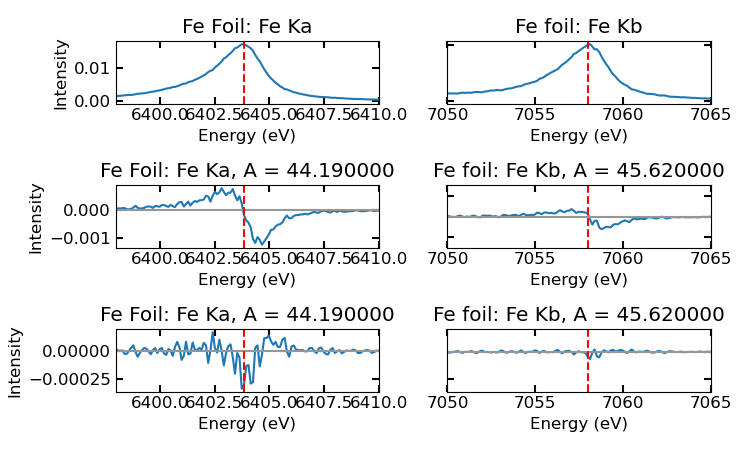

In [10]:
foil_Ka = (np.nanmean(xes1.epix_ROI_1_summed_laser_off_normalized, axis = 0) + np.nanmean(xes1.epix_ROI_1_summed_laser_on_normalized, axis = 0))/2
foil_Kb = (np.nanmean(xes1.epix_ROI_2_summed_laser_off_normalized, axis = 0) + np.nanmean(xes1.epix_ROI_2_summed_laser_on_normalized, axis = 0))/2

fig, ax = plt.subplots(3,2)
ka1_ref = 6403.84
kb13_ref = 7057.98

ax[0,0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, foil_Ka)
ax[0,0].axvline(ka1_ref, color = 'r', linestyle = '--')
# ax[0,0].set_xlim([min(xes1.analyzed_runs[0].epix_ROI_1_energy), 6415])
ax[0,0].set_xlim([6398, 6410])
ax[0,0].set_title('Fe Foil: Fe Ka')
ax[0,0].set_xlabel('Energy (eV)')
ax[0,0].set_ylabel('Intensity')

ax[0,1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, foil_Kb)
ax[0,1].axvline(kb13_ref, color = 'r', linestyle = '--')
ax[0,1].set_xlim([7050, 7065])
ax[0,1].set_title('Fe foil: Fe Kb')
ax[0,1].set_yticklabels([])
ax[0,1].set_xlabel('Energy (eV)')

ax[1,0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.gradient(foil_Ka))
ax[1,0].axhline(0, color = np.array([150, 150, 150])/255)
ax[1,0].axvline(ka1_ref, color = 'r', linestyle = '--')
ax[1,0].set_xlim([6398, 6410])
ax[1,0].set_title('Fe Foil: Fe Ka, A = %f' % xtal1['detector_distance'])
ax[1,0].set_xlabel('Energy (eV)')
ax[1,0].set_ylabel('Intensity')

ax[1,1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.gradient(foil_Kb))
ax[1,1].axhline(0, color = np.array([150, 150, 150])/255)
ax[1,1].axvline(kb13_ref, color = 'r', linestyle = '--')
ax[1,1].set_xlim([7050, 7065])
ax[1,1].set_title('Fe foil: Fe Kb, A = %f' % xtal2['detector_distance'])
ax[1,1].set_yticklabels([])
ax[1,1].set_xlabel('Energy (eV)')

ax[2,0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.gradient(np.gradient(foil_Ka)))
ax[2,0].axhline(0, color = np.array([150, 150, 150])/255)
ax[2,0].axvline(ka1_ref, color = 'r', linestyle = '--')
ax[2,0].set_xlim([6398, 6410])
ax[2,0].set_title('Fe Foil: Fe Ka, A = %f' % xtal1['detector_distance'])
ax[2,0].set_xlabel('Energy (eV)')
ax[2,0].set_ylabel('Intensity')

ax[2,1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.gradient(np.gradient(foil_Kb)))
ax[2,1].axhline(0, color = np.array([150, 150, 150])/255)
ax[2,1].axvline(kb13_ref, color = 'r', linestyle = '--')
ax[2,1].set_xlim([7050, 7065])
ax[2,1].set_title('Fe foil: Fe Kb, A = %f' % xtal2['detector_distance'])
ax[2,1].set_yticklabels([])
ax[2,1].set_xlabel('Energy (eV)')

plt.tight_layout()

## Using SpectrumDerivativeAnalyzer to Determine Corrected Detector Distance: Ka

Output()

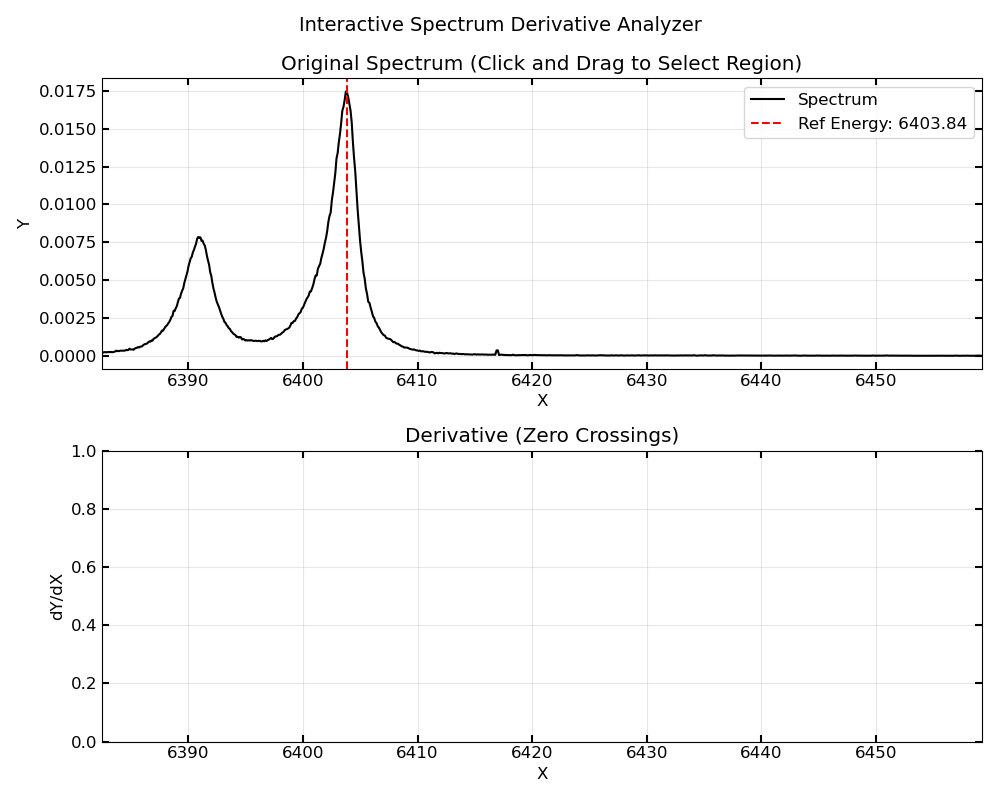

In [11]:
analyzer = XSpect.XSpect_Analysis.SpectrumDerivativeAnalyzer(xtal1, foil_Ka, smooth_window=15, poly_order=3, ref_energy = ka1_ref)
analyzer.show()

## Using SpectrumDerivativeAnalyzer to Determine Corrected Detector Distance: Kb

Output()

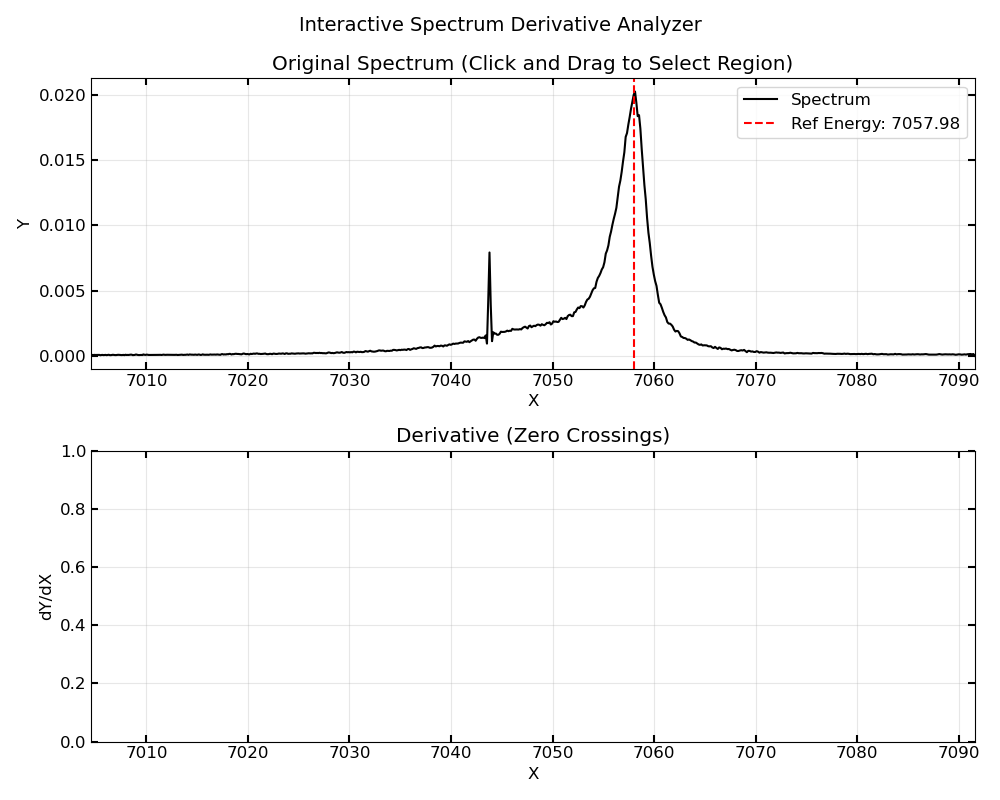

In [12]:
analyzer = XSpect.XSpect_Analysis.SpectrumDerivativeAnalyzer(xtal2, foil_Kb, smooth_window=15, poly_order=3, ref_energy = kb13_ref)
analyzer.show()